In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [2]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 9.65 ms, sys: 5.04 ms, total: 14.7 ms
Wall time: 14.3 ms
CPU times: user 2.68 ms, sys: 3.94 ms, total: 6.62 ms
Wall time: 6.61 ms
CPU times: user 2.14 ms, sys: 1.01 ms, total: 3.15 ms
Wall time: 3.15 ms


In [3]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [4]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history', 'mens', 'womens']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 3 lớp Embedding và 4 lớp Projection.


/tmp/ipykernel_21077/1902134193.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)


In [ ]:
epochs = 150
early_stop_metric = "ema_qini"
ema = True
ema_alpha = 0.25
patience = 20
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")


 epochs = 150
 early stop = ema_qini
 use ema = True
 ema alpha = 0.25
 patience = 20
 early stop start = 30


In [ ]:
import io
import optuna
from contextlib import redirect_stdout, redirect_stderr

# Minimize Optuna console noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Optuna search config (validation only)
seeds = [412312, 42, 1874, 902745, 1]
n_trials = 50
tpe_sampler_seed = 412312
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    grid_lr = trial.suggest_float("lr", 5e-5, 5e-3, log=True)
    grid_wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    grid_outcome_dropout = trial.suggest_float("outcome_dropout", 0.0, 0.7)
    grid_shared_dropout = trial.suggest_float("shared_dropout", 0.0, 0.7)
    grid_shared_hidden = trial.suggest_int("shared_hidden", 32, 500)
    grid_outcome_hidden = trial.suggest_int("outcome_hidden", 32, 500)
    grid_ziln_lambda = trial.suggest_float("ziln_lambda", 1e-4, 0.1, log=True)
    grid_pos_weight = trial.suggest_float("pos_weight", 0.1, 99.0, log=True)
    grid_ema_alpha = trial.suggest_float("ema_alpha", 0.1, 0.4)
    grid_early_stop_start = trial.suggest_int("early_stop_start", 10, 50)


    val_loss_list = []
    for SEED in seeds:
        seed_everything(SEED)

        tarnet = Tarnet(
            cate_dims=cat_dims,
            num_count=num_count,
            epochs=epochs,
            learning_rate=grid_lr,
            weight_decay=grid_wd,
            use_ema=ema,
            ema_alpha=grid_ema_alpha,
            patience=patience,
            shared_hidden=grid_shared_hidden,
            outcome_hidden=grid_outcome_hidden,
            outcome_dropout=grid_outcome_dropout,
            shared_dropout=grid_shared_dropout,
            early_stop_metric="loss",
            early_stop_start_epoch=early_stop_start,
            ziln_lambda=grid_ziln_lambda,
            pos_weight=grid_pos_weight
        )

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            tarnet.fit(train_loader, val_loader)

        current_val_loss = float(tarnet.best_loss)
        if not np.isfinite(current_val_loss):
            current_val_loss = float(tarnet.validate(val_loader))

        val_loss_list.append(current_val_loss)

    # Calculate aggregated loss across the 5 validation seeds
    mean_val_loss = float(np.mean(val_loss_list))
    std_val_loss = float(np.std(val_loss_list))

    trial.set_user_attr("mean_val_loss", mean_val_loss)
    trial.set_user_attr("std_val_loss", std_val_loss)
    return mean_val_loss

def print_trial_callback(study, trial):
    value = float(trial.value) if trial.value is not None else float("nan")
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

    if not completed_trials:
        print(
            f"Finished trial {trial.number}: val loss: {value:.4f} - "
            f"with hyperparameters: {trial.params} | "
            "best trial: N/A (no completed trials yet)",
            flush=True,
        )
        return

    best_trial = study.best_trial
    best_value = float(best_trial.value) if best_trial.value is not None else float("nan")
    print(
        f"Finished trial {trial.number}: val loss: {value:.4f} - "
        f"with hyperparameters: {trial.params} | "
        f"best trial: {best_trial.number} loss: {best_value:.4f}",
        flush=True,
    )

sampler = optuna.samplers.TPESampler(seed=tpe_sampler_seed)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=True, callbacks=[print_trial_callback])

trial_rows = []
for t in study.trials:
    if t.value is None:
        continue
    trial_rows.append({
        "trial": t.number,
        "lr": round(float(t.params["lr"]), 4),
        "weight_decay": round(float(t.params["weight_decay"]), 4),
        "shared_hidden": int(t.params["shared_hidden"]),
        "outcome_hidden": int(t.params["outcome_hidden"]),
        "shared_dropout": round(float(t.params["shared_dropout"]), 3),
        "outcome_dropout": round(float(t.params["outcome_dropout"]), 3),
        "ziln_lambda": round(float(t.params["ziln_lambda"]), 3),
        "pos_weight": round(float(t.params["pos_weight"]), 3),
        "ema_alpha": round(float(t.params["ema_alpha"]), 3),
        "mean_val_loss": float(t.value),
        "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan))
    })

df_grid = pd.DataFrame(trial_rows).sort_values("mean_val_loss", ascending=True).reset_index(drop=True)
best_params = study.best_params
best_cfg = pd.Series({
    "lr": float(best_params["lr"]),
    "weight_decay": float(best_params["weight_decay"]),
    "shared_hidden": int(best_params["shared_hidden"]),
    "outcome_hidden": int(best_params["outcome_hidden"]),
    "shared_dropout": float(best_params["shared_dropout"]),
    "outcome_dropout": float(best_params["outcome_dropout"]),
    "ziln_lambda": float(best_params["ziln_lambda"]),
    "pos_weight": float(best_params["pos_weight"]),
    "ema_alpha": float(best_params["ema_alpha"]),
    "mean_val_loss": float(study.best_value),
    "std_val_loss": float(study.best_trial.user_attrs.get("std_val_loss", np.nan))
})

/home/ducvu0904/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/50 [00:00<?, ?it/s]

Finished trial 0: val score: 0.5027 - with hyperparameters: {'lr': 0.00019421195391169398, 'weight_decay': 3.2543813547868006e-05, 'outcome_dropout': 0.285791981486852, 'shared_dropout': 0.3103695462655224, 'shared_hidden': 314, 'outcome_hidden': 416, 'ziln_lambda': 0.06371867322051755, 'pos_weight': 85.58273522042343, 'ema_alpha': 0.27706978682774963} | best trial: 0 score: 0.5027


Best trial: 0. Best value: 0.502743:   2%|▏         | 1/50 [01:32<1:15:20, 92.26s/it]

Finished trial 1: val score: 0.8524 - with hyperparameters: {'lr': 0.0009864292971556092, 'weight_decay': 0.0018865375430062972, 'outcome_dropout': 0.21781161962472378, 'shared_dropout': 0.2919863338576562, 'shared_hidden': 112, 'outcome_hidden': 133, 'ziln_lambda': 0.010085829414078899, 'pos_weight': 19.90662037605242, 'ema_alpha': 0.2821789066860085} | best trial: 1 score: 0.8524


Best trial: 1. Best value: 0.852356:   4%|▍         | 2/50 [03:39<1:30:13, 112.78s/it]

...

Best trial: 37. Best value: 0.937322:  96%|█████████▌| 48/50 [1:56:59<06:30, 195.07s/it]

Finished trial 48: val score: 0.8646 - with hyperparameters: {'lr': 0.000367643395987249, 'weight_decay': 0.003566482674586649, 'outcome_dropout': 0.17370889634105363, 'shared_dropout': 0.23824409992037587, 'shared_hidden': 148, 'outcome_hidden': 94, 'ziln_lambda': 0.02824830387399135, 'pos_weight': 9.573633048002035, 'ema_alpha': 0.15353081960688214} | best trial: 37 score: 0.9373


Best trial: 37. Best value: 0.937322:  98%|█████████▊| 49/50 [1:59:32<03:02, 182.41s/it]

Finished trial 49: val score: 0.7280 - with hyperparameters: {'lr': 0.0008060019477550254, 'weight_decay': 0.0012000192259353567, 'outcome_dropout': 0.24483091579902277, 'shared_dropout': 0.1795424720444364, 'shared_hidden': 362, 'outcome_hidden': 237, 'ziln_lambda': 0.01853357120540268, 'pos_weight': 42.563741768881634, 'ema_alpha': 0.2194171829160107} | best trial: 37 score: 0.9373


Best trial: 37. Best value: 0.937322: 100%|██████████| 50/50 [2:01:22<00:00, 145.65s/it]


In [ ]:
from IPython.display import display

if 'study' not in globals():
    print('Run Cell 6 (Optuna tuning) first.')
else:
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best mean_Val_Loss: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

if 'best_cfg' in globals():
    print('\nBest config table:')
    display(best_cfg.to_frame().T)
else:
    print('\nbest_cfg not found.')

if 'df_grid' in globals():
    print('\nTop 10 trials:')
    display(df_grid.head(10))
else:
    print('\ndf_grid not found.')

if 'df_results' in globals():
    print('\nPer-seed test results:')
    display(df_results)
    print('\nTest metrics mean ± std:')
    display(df_results.drop(columns='Seed').agg(['mean', 'std']))

Best trial: 37
Best mean_Val_AUQC: 0.937322
Best params: {'lr': 0.00045919381018505424, 'weight_decay': 0.004869324403371972, 'outcome_dropout': 0.21244316063646956, 'shared_dropout': 0.30121792306159373, 'shared_hidden': 127, 'outcome_hidden': 126, 'ziln_lambda': 0.005823217712245453, 'pos_weight': 60.846407644763396, 'ema_alpha': 0.20712422040008244}

Best config table:


,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ziln_lambda,pos_weight,ema_alpha,mean_Val_auqc,std_Val_auqc
0,0.000459,0.004869,127.0,126.0,0.301218,0.212443,0.005823,60.846408,0.207124,0.937322,0.017268



Top 10 trials:


,trial,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,ziln_lambda,pos_weight,ema_alpha,mean_val_auqc,std_Val_auqc
0,7,0.0011,0.0033,396,160,0.288,0.404,0.020,0.266,0.180,-0.109315,0.312477
1,15,0.0021,0.0089,268,78,0.531,0.108,0.001,3.084,0.336,0.000000,0.000000
2,13,0.0046,0.0005,168,37,0.524,0.012,0.000,1.564,0.393,0.000000,0.000000
3,16,0.0030,0.0004,121,262,0.589,0.064,0.000,0.797,0.366,0.000000,0.000000
4,17,0.0019,0.0077,56,207,0.463,0.191,0.001,3.660,0.299,0.000000,0.000000
5,22,0.0037,0.0030,228,97,0.623,0.095,0.001,2.073,0.359,0.000000,0.000000
6,33,0.0017,0.0043,183,107,0.581,0.403,0.001,2.130,0.288,0.000000,0.000000
7,26,0.0003,0.0002,95,183,0.478,0.232,0.000,0.753,0.310,0.132049,0.039946
8,6,0.0005,0.0000,109,249,0.007,0.651,0.065,0.400,0.164,0.375965,0.148994
9,29,0.0002,0.0002,37,439,0.358,0.272,0.000,41.702,0.276,0.419751,0.143096


🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.1271 | Cls: 0.0758 | Reg: 1.0513 | mu_t: 4.3064 | sigma_t: 0.9651 | mu_c: 4.4414 | sigma_c: 0.9511 | Val Loss: 1.4599 | F1_c: 0.0000 | PR_AUC_c: 0.0043 | F1_t: 0.0741 | PR_AUC_t: 0.0319 | Val Qini: 0.8353 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 0.5265 | Cls: 0.0475 | Reg: 0.4790 | mu_t: 4.4616 | sigma_t: 0.9531 | mu_c: 4.4165 | sigma_c: 0.8367 | Val Loss: 1.4595 | F1_c: 0.0000 | PR_AUC_c: 0.0047 | F1_t: 0.0000 | PR_AUC_t: 0.0190 | Val Qini: 0.8232 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 1.0928 | Cls: 0.0761 | Reg: 1.0167 | mu_t: 4.4131 | sigma_t: 0.8918 | mu_c: 4.3246 | sigma_c: 0.8575 | Val 

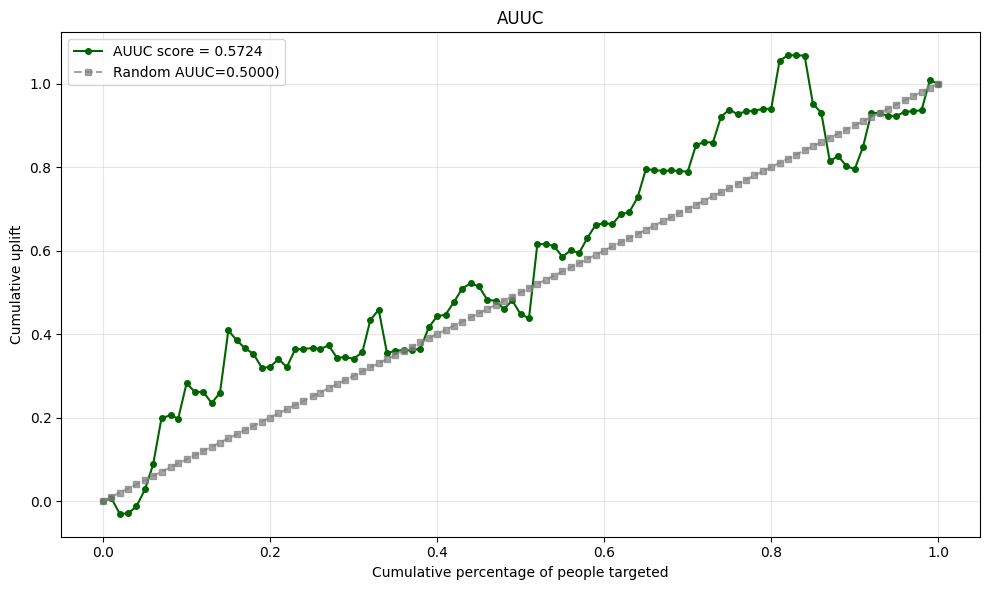

  Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.0191 | Cls: 0.0759 | Reg: 0.9432 | mu_t: 4.4178 | sigma_t: 0.9643 | mu_c: 4.3217 | sigma_c: 0.8412 | Val Loss: 1.4581 | F1_c: 0.0000 | PR_AUC_c: 0.0044 | F1_t: 0.0000 | PR_AUC_t: 0.0270 | Val Qini: 0.9242 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 1.3146 | Cls: 0.0817 | Reg: 1.2328 | mu_t: 4.4208 | sigma_t: 0.7551 | mu_c: 4.3924 | sigma_c: 0.8360 | Val Loss: 1.4968 | F1_c: 0.0000 | PR_AUC_c: 0.0046 | F1_t: 0.0000 | PR_AUC_t: 0.0223 | Val Qini: 0.8398 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 1.6697 | Cls: 0.0944 | Reg: 1.5753 | mu_t: 4.4049 | sigma_t: 0.8605 | mu_c: 4.4028 | sig

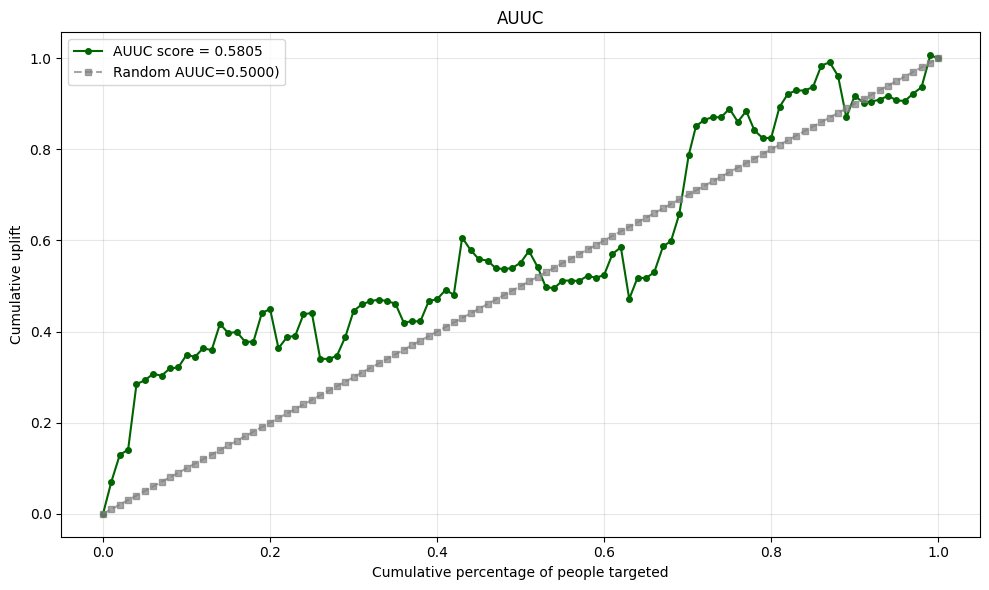

  Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.4961 | Cls: 0.0959 | Reg: 1.4002 | mu_t: 4.3679 | sigma_t: 0.9847 | mu_c: 4.2851 | sigma_c: 0.8155 | Val Loss: 1.4583 | F1_c: 0.0000 | PR_AUC_c: 0.0048 | F1_t: 0.0000 | PR_AUC_t: 0.0153 | Val Qini: 0.7387 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 0.9416 | Cls: 0.0644 | Reg: 0.8772 | mu_t: 4.4142 | sigma_t: 0.8578 | mu_c: 4.4104 | sigma_c: 0.8778 | Val Loss: 1.4652 | F1_c: 0.0000 | PR_AUC_c: 0.0045 | F1_t: 0.0000 | PR_AUC_t: 0.0161 | Val Qini: 0.8252 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 2.6695 | Cls: 0.1609 | Reg: 2.5086 | mu_t: 4.3858 | sigma_t: 0.9093 | mu_c: 4.4142 | sigma_c

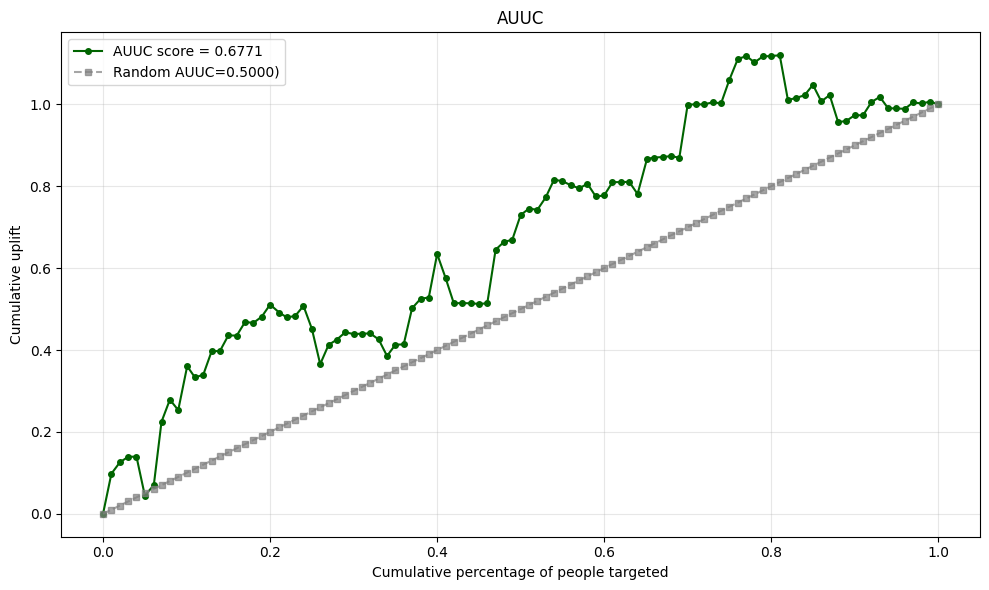

  Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 2.3639 | Cls: 0.1301 | Reg: 2.2338 | mu_t: 4.5097 | sigma_t: 0.8998 | mu_c: 4.3490 | sigma_c: 0.7647 | Val Loss: 1.4650 | F1_c: 0.0000 | PR_AUC_c: 0.0050 | F1_t: 0.0000 | PR_AUC_t: 0.0201 | Val Qini: 0.6681 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 1.6487 | Cls: 0.1025 | Reg: 1.5462 | mu_t: 4.4708 | sigma_t: 0.8085 | mu_c: 4.3619 | sigma_c: 0.6656 | Val Loss: 1.4784 | F1_c: 0.0000 | PR_AUC_c: 0.0051 | F1_t: 0.0000 | PR_AUC_t: 0.0181 | Val Qini: 0.6881 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 0.8502 | Cls: 0.0567 | Reg: 0.7935 | mu_t: 4.4035 | sigma_t: 0.8191 | mu_c: 4.3578 | sigma

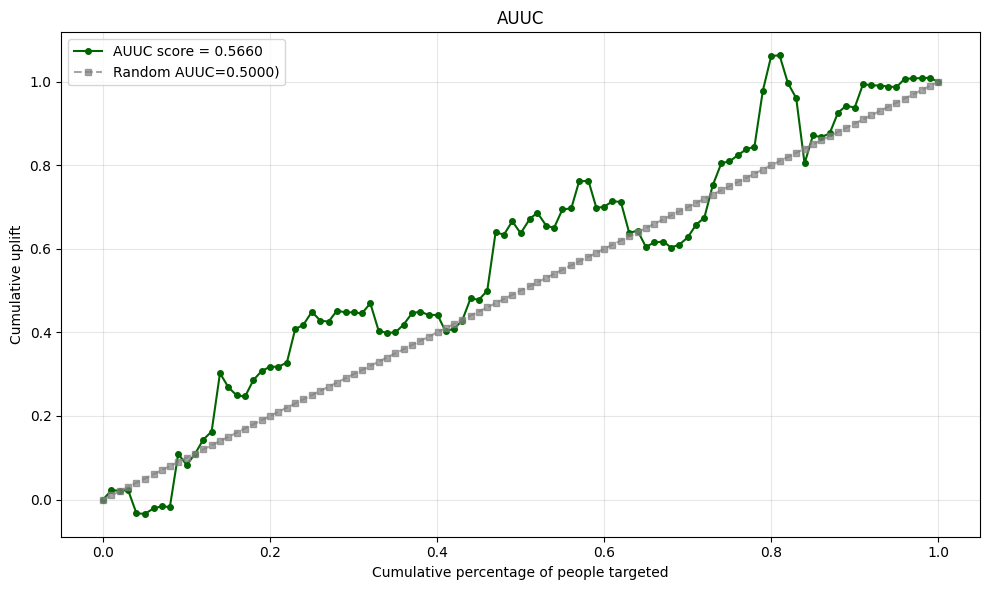

  Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 2.0133 | Cls: 0.1219 | Reg: 1.8913 | mu_t: 4.3664 | sigma_t: 1.1081 | mu_c: 4.3322 | sigma_c: 0.9684 | Val Loss: 1.4634 | F1_c: 0.0000 | PR_AUC_c: 0.0042 | F1_t: 0.0000 | PR_AUC_t: 0.0128 | Val Qini: 0.8664 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 1.7588 | Cls: 0.0965 | Reg: 1.6623 | mu_t: 4.4348 | sigma_t: 0.8793 | mu_c: 4.3738 | sigma_c: 0.8469 | Val Loss: 1.4630 | F1_c: 0.0000 | PR_AUC_c: 0.0043 | F1_t: 0.0000 | PR_AUC_t: 0.0223 | Val Qini: 0.9156 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 1.4986 | Cls: 0.0950 | Reg: 1.4036 | mu_t: 4.3683 | sigma_t: 0.9528 | mu_c: 4.3746 | sig

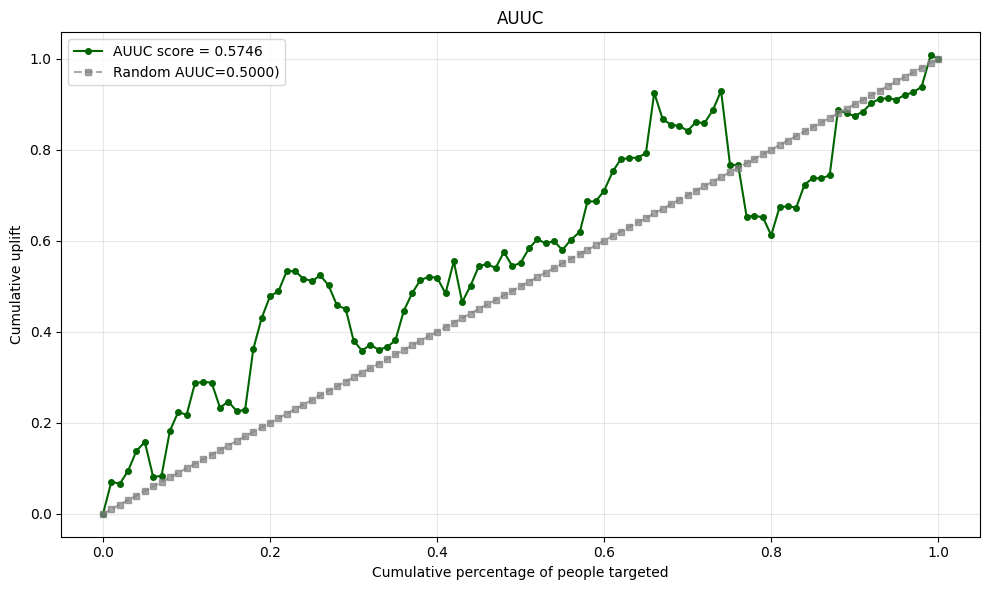

  Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.8330 | Cls: 0.1121 | Reg: 1.7210 | mu_t: 4.4490 | sigma_t: 0.9158 | mu_c: 4.4983 | sigma_c: 0.9096 | Val Loss: 1.4646 | F1_c: 0.0000 | PR_AUC_c: 0.0051 | F1_t: 0.0000 | PR_AUC_t: 0.0255 | Val Qini: 0.8788 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 2.3481 | Cls: 0.1312 | Reg: 2.2169 | mu_t: 4.3709 | sigma_t: 1.0402 | mu_c: 4.3715 | sigma_c: 0.9655 | Val Loss: 1.4607 | F1_c: 0.0000 | PR_AUC_c: 0.0051 | F1_t: 0.0000 | PR_AUC_t: 0.0216 | Val Qini: 0.8852 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 0.6542 | Cls: 0.0553 | Reg: 0.5989 | mu_t: 4.3282 | sigma_t: 0.8406 | mu_c: 4.4300 | sigma_c:

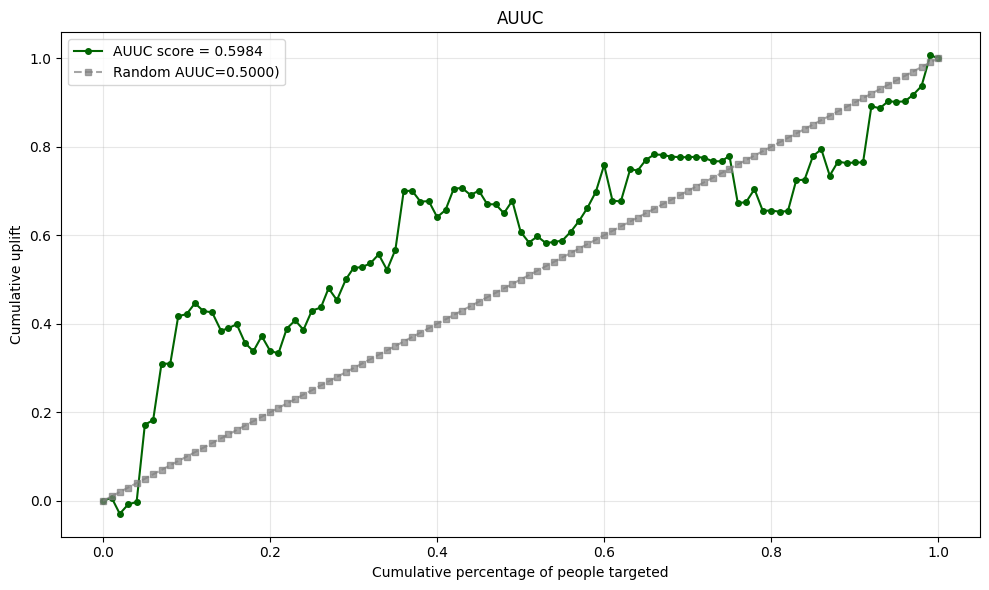

  Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.1416 | Cls: 0.0757 | Reg: 1.0659 | mu_t: 4.3928 | sigma_t: 1.0193 | mu_c: 4.3644 | sigma_c: 0.8873 | Val Loss: 1.4588 | F1_c: 0.0000 | PR_AUC_c: 0.0056 | F1_t: 0.0370 | PR_AUC_t: 0.0211 | Val Qini: 0.8445 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 2.1163 | Cls: 0.1204 | Reg: 1.9958 | mu_t: 4.4268 | sigma_t: 0.9012 | mu_c: 4.3518 | sigma_c: 0.8792 | Val Loss: 1.4616 | F1_c: 0.0000 | PR_AUC_c: 0.0049 | F1_t: 0.0370 | PR_AUC_t: 0.0225 | Val Qini: 0.8191 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 1.3931 | Cls: 0.0948 | Reg: 1.2983 | mu_t: 4.4025 | sigma_t: 0.9960 | mu_c: 4.4163 | sigma_c:

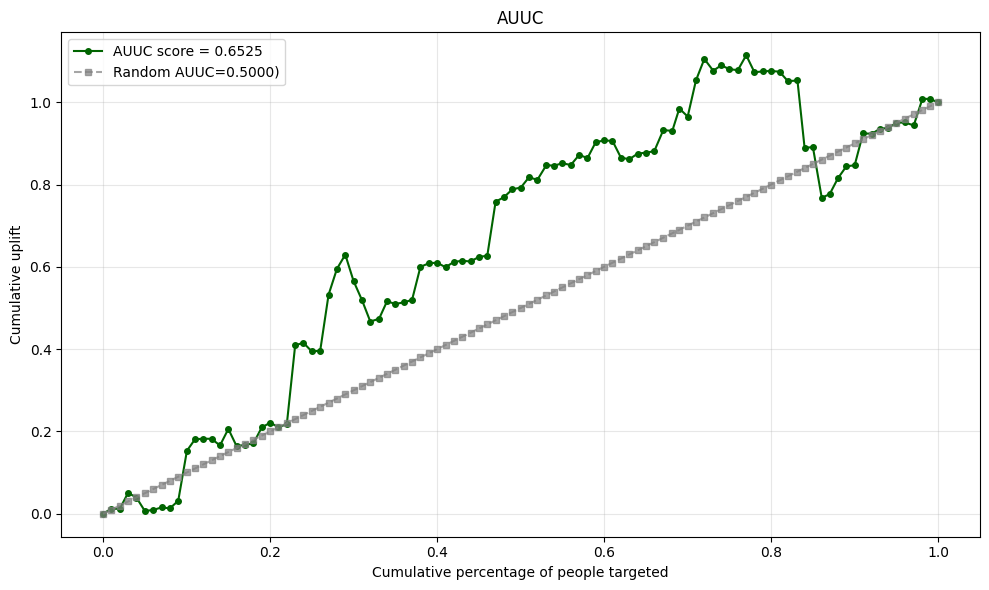

  Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.2365 | Cls: 0.0844 | Reg: 1.1521 | mu_t: 4.3176 | sigma_t: 0.9507 | mu_c: 4.5302 | sigma_c: 0.9202 | Val Loss: 1.4611 | F1_c: 0.0000 | PR_AUC_c: 0.0050 | F1_t: 0.0000 | PR_AUC_t: 0.0173 | Val Qini: 0.8074 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 2.8861 | Cls: 0.1663 | Reg: 2.7198 | mu_t: 4.3957 | sigma_t: 0.9200 | mu_c: 4.4278 | sigma_c: 0.9204 | Val Loss: 1.4617 | F1_c: 0.0000 | PR_AUC_c: 0.0051 | F1_t: 0.0000 | PR_AUC_t: 0.0161 | Val Qini: 0.9170 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 2.1986 | Cls: 0.1325 | Reg: 2.0661 | mu_t: 4.4075 | sigma_t: 0.8901 | mu_c: 4.4260 | sigma_c:

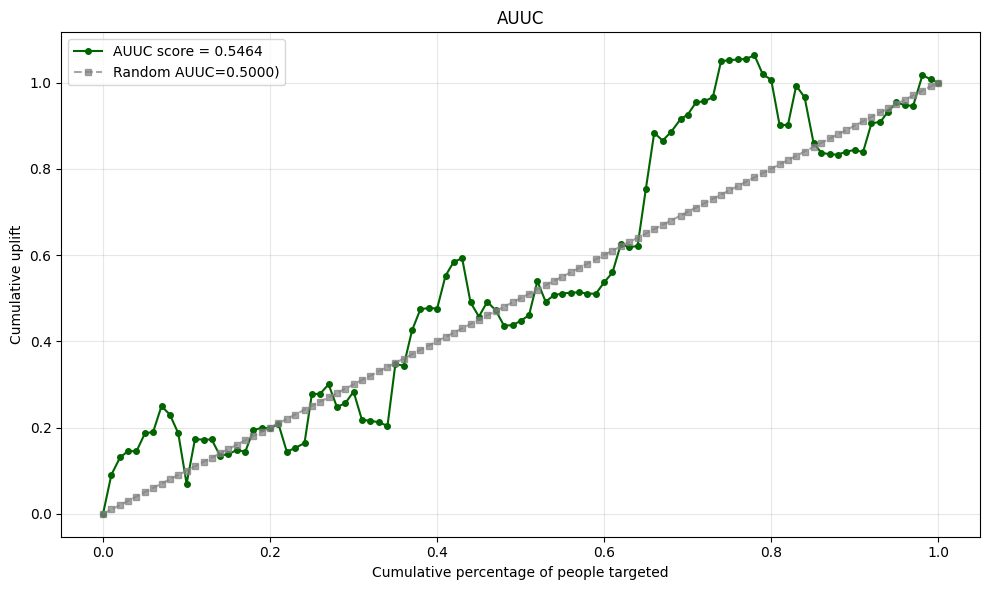

  Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 0.7797 | Cls: 0.0560 | Reg: 0.7238 | mu_t: 4.3589 | sigma_t: 0.9601 | mu_c: 4.4035 | sigma_c: 0.8467 | Val Loss: 1.4584 | F1_c: 0.0000 | PR_AUC_c: 0.0045 | F1_t: 0.0741 | PR_AUC_t: 0.0270 | Val Qini: 0.9110 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 1.5369 | Cls: 0.0939 | Reg: 1.4430 | mu_t: 4.4199 | sigma_t: 0.8291 | mu_c: 4.4063 | sigma_c: 0.8740 | Val Loss: 1.4675 | F1_c: 0.0000 | PR_AUC_c: 0.0050 | F1_t: 0.0000 | PR_AUC_t: 0.0180 | Val Qini: 0.8511 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 2.3244 | Cls: 0.1428 | Reg: 2.1816 | mu_t: 4.3674 | sigma_t: 0.9072 | mu_c: 4.4050 | sigma_c:

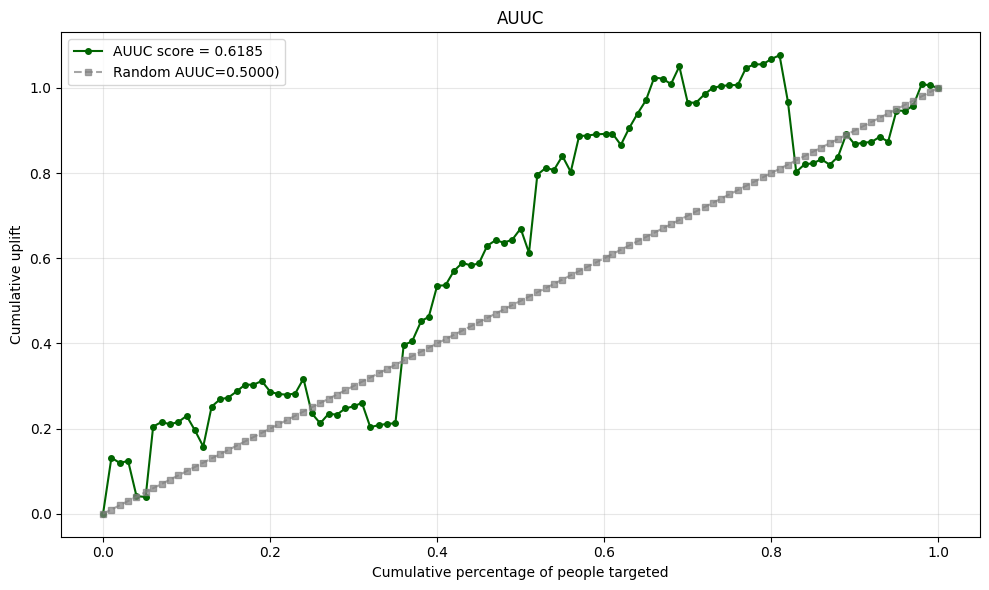

  Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 51
📊 Score Selection Start Epoch: 51 (ignore earlier epochs)
📊 Strategy: Best EMA Qini (alpha=0.3)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Loss: 1.8964 | Cls: 0.1124 | Reg: 1.7840 | mu_t: 4.2607 | sigma_t: 0.9112 | mu_c: 4.1719 | sigma_c: 0.7647 | Val Loss: 1.4593 | F1_c: 0.0000 | PR_AUC_c: 0.0040 | F1_t: 0.0370 | PR_AUC_t: 0.0159 | Val Qini: 0.8429 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 2/150 | Loss: 1.4898 | Cls: 0.0955 | Reg: 1.3943 | mu_t: 4.4057 | sigma_t: 0.8154 | mu_c: 4.4312 | sigma_c: 0.8518 | Val Loss: 1.4719 | F1_c: 0.0000 | PR_AUC_c: 0.0042 | F1_t: 0.0000 | PR_AUC_t: 0.0229 | Val Qini: 0.8352 | EMA Qini: N/A | Best EMA: N/A (ignored before score selection start epoch)
Epoch 3/150 | Loss: 1.2722 | Cls: 0.0849 | Reg: 1.1873 | mu_t: 4.3681 | sigma_t: 0.9471 | mu_c: 4.4815 | sigma_c:

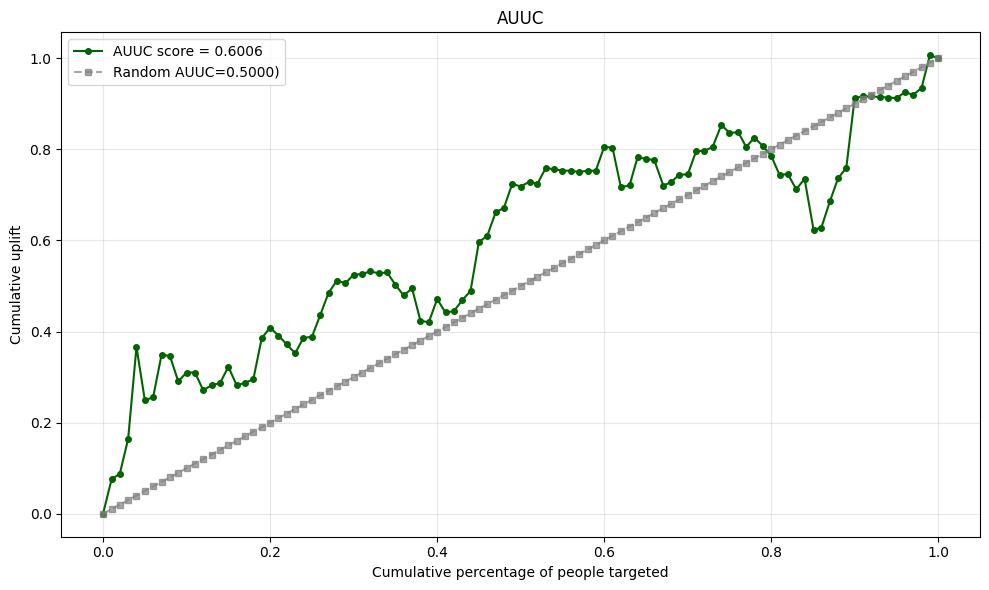

  Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC   Lift    KRCC ATE_Err
412312 0.5724 0.5725 0.6676  0.0202  0.1632
    42 0.5805 0.5797 0.8719  0.0348  0.0391
  1874 0.6771 0.6772 0.8598  0.0882  0.1057
902745 0.5660 0.5656 0.8781  0.0209  0.0929
     1 0.5746 0.5746 0.7460  0.0412  0.1180
     2 0.5984 0.5971 1.0309 -0.0023  0.0593
     3 0.6525 0.6534 1.1075  0.0343  0.1844
     4 0.5464 0.5468 0.5553  0.0371  0.2316
     5 0.6185 0.6177 0.4945 -0.0159  0.0570
     6 0.6006 0.6001 1.0268  0.0399  0.1705
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.5987 ± 0.0406
AUQC      : 0.5985 ± 0.0407
Lift      : 0.8238 ± 0.2061
KRCC      : 0.0298 ± 0.0280
ATE_Err   : 0.1222 ± 0.0633


In [ ]:
import pandas as pd
import numpy as np
import torch

# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

if 'best_cfg' not in globals():
    raise ValueError("best_cfg not found. Run grid-search cell first.")

best_lr = float(best_cfg['lr'])
best_wd = float(best_cfg['weight_decay'])
best_shared_hidden = int(best_cfg['shared_hidden'])
best_outcome_hidden = int(best_cfg['outcome_hidden'])
best_shared_dropout = float(best_cfg['shared_dropout'])
best_outcome_dropout = float(best_cfg['outcome_dropout'])
best_ziln_lambda = float(best_cfg['ziln_lambda'])
best_pos_weight = float(best_cfg['pos_weight'])
best_ema_alpha = float(best_cfg['ema_alpha'])

print("Evaluating on test with best validation config:")
print(f"  lr={best_lr:.1e}, weight_decay={best_wd:.1e}")
print(f"  shared_hidden={best_shared_hidden}, outcome_hidden={best_outcome_hidden}")
print(f"  shared_dropout={best_shared_dropout:.3f}, outcome_dropout={best_outcome_dropout:.3f}")
print(f"  ema_alpha={best_ema_alpha:.3f}")
print(f"Number of seeds: {len(seeds)}")

# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=150,
        learning_rate=best_lr,
        weight_decay=best_wd,
        use_ema=False,
        ema_alpha=best_ema_alpha,
        patience=patience,
        shared_hidden=best_shared_hidden,
        outcome_hidden=best_outcome_hidden,
        outcome_dropout=best_outcome_dropout,
        shared_dropout=best_shared_dropout,
        early_stop_metric="ema_qini",
        early_stop_start_epoch=50,
        ziln_lambda=best_ziln_lambda,
        pos_weight=best_pos_weight
    )

    tarnet.fit(train_loader, val_loader)

   # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=False),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"  Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)

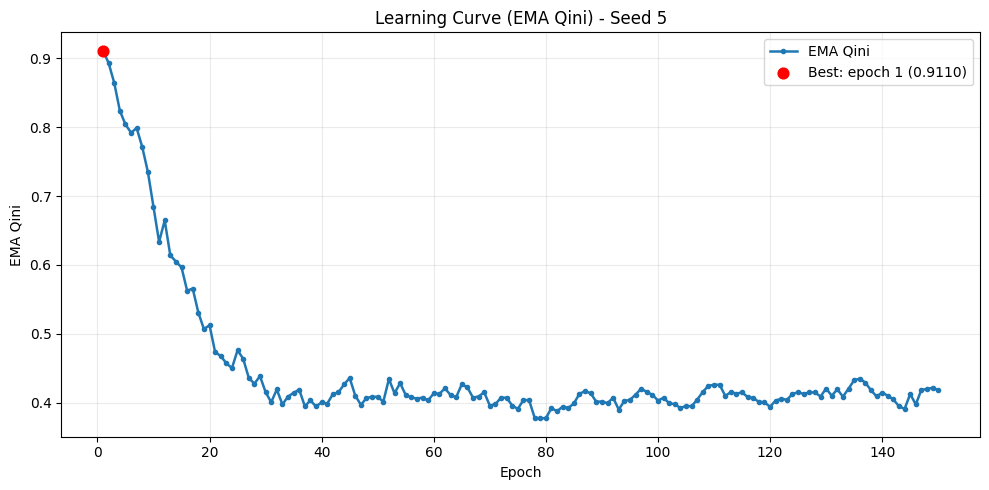

Parsed 150 EMA Qini points.
Best EMA Qini: 0.9110 at epoch 1


In [19]:
import re
import io
from contextlib import redirect_stdout, redirect_stderr
import matplotlib.pyplot as plt

# Plot learning curve (EMA Qini) for one specific seed
seed_to_plot = 5

seed_everything(seed_to_plot)
tarnet_seed = Tarnet(
    cate_dims=cat_dims,
    num_count=num_count,
    epochs=150,
    learning_rate=1e-3,
    weight_decay=1e-5,
    use_ema=True,
    ema_alpha=0.3,
    patience=150,
    shared_hidden=200,
    outcome_hidden=100,
    outcome_dropout=0.0,
    shared_dropout=0.0,
    early_stop_metric="ema_qini",
    early_stop_start_epoch=0,
    ziln_lambda=1,
    pos_weight=1,
    
 )

# Capture training logs so we can parse EMA Qini per epoch
buffer = io.StringIO()
with redirect_stdout(buffer), redirect_stderr(buffer):
    tarnet_seed.fit(train_loader, val_loader)

train_log = buffer.getvalue()

# Parse lines like: "Epoch 51/150 ... EMA Qini: 0.4619 ..."
pattern = re.compile(r"Epoch\s+(\d+)/(\d+).*?EMA Qini:\s+([0-9]*\.?[0-9]+|N/A)")
epochs_curve, ema_qini_curve = [], []

for line in train_log.splitlines():
    m = pattern.search(line)
    if not m:
        continue
    epoch_idx = int(m.group(1))
    ema_val = m.group(3)
    if ema_val == "N/A":
        continue
    epochs_curve.append(epoch_idx)
    ema_qini_curve.append(float(ema_val))

if len(epochs_curve) == 0:
    raise ValueError("No EMA Qini values found. Check early_stop_metric='ema_qini' and training logs.")

best_i = int(max(range(len(ema_qini_curve)), key=lambda i: ema_qini_curve[i]))

plt.figure(figsize=(10, 5))
plt.plot(epochs_curve, ema_qini_curve, marker='o', linewidth=1.8, markersize=3, label='EMA Qini')
plt.scatter(
    [epochs_curve[best_i]],
    [ema_qini_curve[best_i]],
    color='red',
    s=60,
    zorder=3,
    label=f"Best: epoch {epochs_curve[best_i]} ({ema_qini_curve[best_i]:.4f})"
 )
plt.title(f"Learning Curve (EMA Qini) - Seed {seed_to_plot}")
plt.xlabel("Epoch")
plt.ylabel("EMA Qini")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Parsed {len(ema_qini_curve)} EMA Qini points.")
print(f"Best EMA Qini: {ema_qini_curve[best_i]:.4f} at epoch {epochs_curve[best_i]}")